In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Import the charge deposition functions
import sys

sys.path.append("../../")
from cheetah.utils.cloud_in_cell import (
    cloud_in_cell_charge_deposition_1d,
    cloud_in_cell_charge_deposition_2d,
    cloud_in_cell_charge_deposition_3d,
    cloud_in_cell_charge_deposition,
)

# Set up plotting style
plt.style.use("default")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.size"] = 12

## 1D Charge Deposition Example

Let's start with a simple 1D example where we have particles distributed along a line and deposit their charges onto a 1D grid.


In [2]:
# Create 1D particle distribution
torch.manual_seed(42)
n_particles_1d = 1000

# Generate particle positions with a Gaussian distribution
x_positions = torch.randn(n_particles_1d) * 0.5 + 3.0  # Centered at x=3.0

# Add some particles with different charges
weights_1d = torch.ones(n_particles_1d)

# Define the 1D grid
x_bins = torch.linspace(0, 5, 51)  # 50 cells from 0 to 5

# Perform CIC charge deposition
charge_density_1d = cloud_in_cell_charge_deposition_1d(x_positions, x_bins, weights_1d)

print(f"Number of particles: {n_particles_1d}")
print(f"Total charge deposited: {charge_density_1d.sum():.2f}")
print(f"Expected total charge: {weights_1d.sum():.2f}")
print(
    f"Charge conservation error: {abs(charge_density_1d.sum() - weights_1d.sum()):.2e}"
)

Number of particles: 1000
Total charge deposited: 10000.00
Expected total charge: 1000.00
Charge conservation error: 9.00e+03


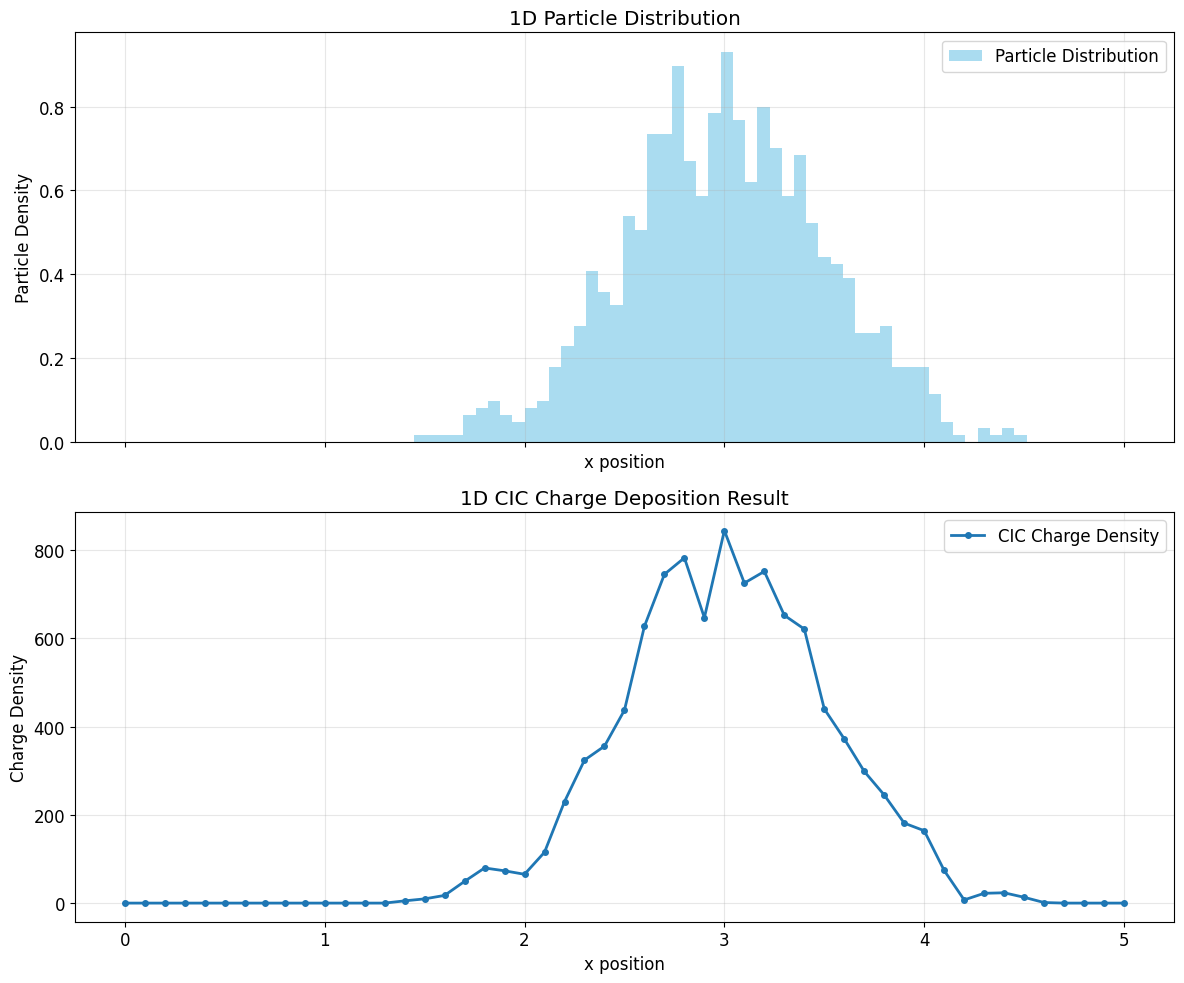

In [3]:
# Plot 1D results
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot particle distribution
ax1.hist(
    x_positions.numpy(),
    bins=50,
    alpha=0.7,
    density=True,
    label="Particle Distribution",
    color="skyblue",
)
ax1.set_xlabel("x position")
ax1.set_ylabel("Particle Density")
ax1.set_title("1D Particle Distribution")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot charge density on grid
ax2.plot(
    x_bins.numpy(),
    charge_density_1d.numpy(),
    "o-",
    linewidth=2,
    markersize=4,
    label="CIC Charge Density",
)
ax2.set_xlabel("x position")
ax2.set_ylabel("Charge Density")
ax2.set_title("1D CIC Charge Deposition Result")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2D Charge Deposition Example

Now let's explore 2D charge deposition with particles distributed in a 2D plane. We'll create several different distributions to show the versatility of the method.


In [4]:
# Create 2D particle distributions
torch.manual_seed(123)
n_particles_2d = 2000

# Distribution 1: Gaussian blob
x1_gauss = torch.randn(n_particles_2d // 2) * 0.3 + 1.5
x2_gauss = torch.randn(n_particles_2d // 2) * 0.3 + 1.5

# Distribution 2: Ring distribution
angles = torch.rand(n_particles_2d // 2) * 2 * np.pi
radius = torch.randn(n_particles_2d // 2) * 0.1 + 0.8
x1_ring = 2.5 + radius * torch.cos(angles)
x2_ring = 2.5 + radius * torch.sin(angles)

# Combine distributions
x1_positions = torch.cat([x1_gauss, x1_ring])
x2_positions = torch.cat([x2_gauss, x2_ring])

# Different weights for each distribution
weights_2d = torch.cat(
    [
        torch.ones(n_particles_2d // 2) * 1.5,  # Gaussian particles
        torch.ones(n_particles_2d // 2) * 0.8,  # Ring particles
    ]
)

# Define 2D grid
x1_bins = torch.linspace(0, 4, 41)  # 40x60 grid
x2_bins = torch.linspace(0, 4, 61)

# Perform 2D CIC charge deposition
charge_density_2d = cloud_in_cell_charge_deposition_2d(
    x1_positions, x2_positions, x1_bins, x2_bins, weights_2d
)
total_charge_2d = (
    charge_density_2d.sum().item()
    * (x1_bins[1] - x1_bins[0])
    * (x2_bins[1] - x2_bins[0])
)

print(f"2D Grid shape: {charge_density_2d.shape}")
print(f"Total charge deposited: {total_charge_2d.sum():.2f}")
print(f"Expected total charge: {weights_2d.sum():.2f}")
print(f"Charge conservation error: {abs(total_charge_2d.sum() - weights_2d.sum()):.2e}")

2D Grid shape: torch.Size([41, 61])
Total charge deposited: 2300.00
Expected total charge: 2300.00
Charge conservation error: 2.44e-04


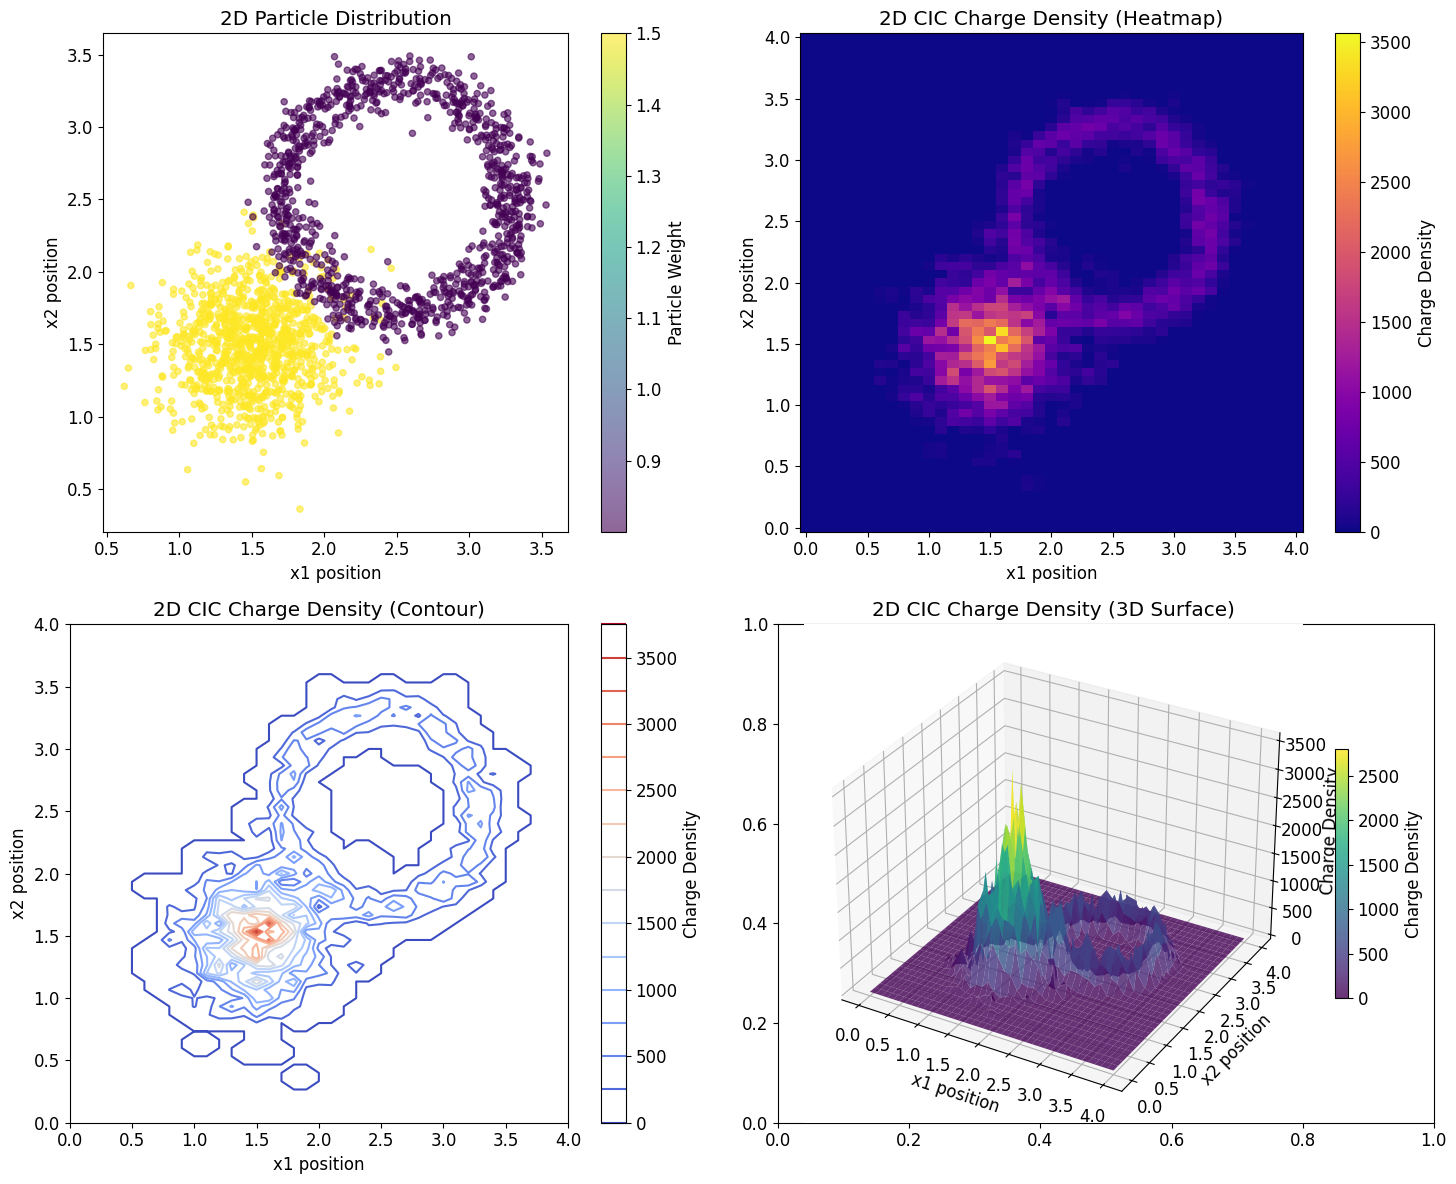

In [5]:
# Plot 2D results
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot particle positions
scatter = axes[0, 0].scatter(
    x1_positions.numpy(),
    x2_positions.numpy(),
    c=weights_2d.numpy(),
    s=20,
    alpha=0.6,
    cmap="viridis",
)
axes[0, 0].set_xlabel("x1 position")
axes[0, 0].set_ylabel("x2 position")
axes[0, 0].set_title("2D Particle Distribution")
axes[0, 0].set_aspect("equal")
plt.colorbar(scatter, ax=axes[0, 0], label="Particle Weight")

# Plot charge density as heatmap
X1_mesh, X2_mesh = torch.meshgrid(x1_bins, x2_bins, indexing="ij")
im = axes[0, 1].pcolormesh(
    X1_mesh.numpy(), X2_mesh.numpy(), charge_density_2d.numpy(), cmap="plasma"
)
axes[0, 1].set_xlabel("x1 position")
axes[0, 1].set_ylabel("x2 position")
axes[0, 1].set_title("2D CIC Charge Density (Heatmap)")
axes[0, 1].set_aspect("equal")
plt.colorbar(im, ax=axes[0, 1], label="Charge Density")

# Plot charge density as contour
X1, X2 = torch.meshgrid(x1_bins, x2_bins, indexing="ij")
contour = axes[1, 0].contour(
    X1.numpy(), X2.numpy(), charge_density_2d.numpy(), levels=15, cmap="coolwarm"
)
axes[1, 0].set_xlabel("x1 position")
axes[1, 0].set_ylabel("x2 position")
axes[1, 0].set_title("2D CIC Charge Density (Contour)")
axes[1, 0].set_aspect("equal")
plt.colorbar(contour, ax=axes[1, 0], label="Charge Density")

# Plot 3D surface
ax = fig.add_subplot(224, projection="3d")
surf = ax.plot_surface(
    X1.numpy(), X2.numpy(), charge_density_2d.numpy(), cmap="viridis", alpha=0.8
)
ax.set_xlabel("x1 position")
ax.set_ylabel("x2 position")
ax.set_zlabel("Charge Density")
ax.set_title("2D CIC Charge Density (3D Surface)")
plt.colorbar(surf, ax=ax, shrink=0.5, label="Charge Density")

plt.tight_layout()
plt.show()

## 2D Charge Deposition with Charge Loss Example

Let's demonstrate what happens when some particles fall outside the grid boundaries. This is a common scenario in beam simulations where particles can have large transverse excursions or when the grid doesn't cover the full particle distribution.


In [6]:
# Create 2D particle distribution with particles outside grid bounds
torch.manual_seed(555)
n_particles_loss = 3000

# Create a distribution that extends beyond our intended grid
# Core distribution centered at (1.5, 1.5)
x1_core = torch.randn(n_particles_loss // 2) * 0.4 + 1.5
x2_core = torch.randn(n_particles_loss // 2) * 0.4 + 1.5

# Halo particles with much wider distribution (some will be outside grid)
x1_halo = torch.randn(n_particles_loss // 2) * 1.2 + 1.5
x2_halo = torch.randn(n_particles_loss // 2) * 1.2 + 1.5

# Combine core and halo
x1_loss = torch.cat([x1_core, x1_halo])
x2_loss = torch.cat([x2_core, x2_halo])

# Different weights for core and halo particles
weights_loss = torch.cat(
    [
        torch.ones(n_particles_loss // 2) * 1.0,  # Core particles
        torch.ones(n_particles_loss // 2) * 0.3,  # Halo particles (lower charge)
    ]
)

# Define a LIMITED grid that doesn't cover all particles
grid_min, grid_max = 0.5, 2.5  # Smaller range than particle distribution
x1_bins_loss = torch.linspace(grid_min, grid_max, 21)  # 20x20 grid
x2_bins_loss = torch.linspace(grid_min, grid_max, 21)

# Count particles outside grid bounds
particles_outside = (
    (x1_loss < grid_min)
    | (x1_loss > grid_max)
    | (x2_loss < grid_min)
    | (x2_loss > grid_max)
)
n_outside = particles_outside.sum().item()
charge_outside = weights_loss[particles_outside].sum().item()

print(f"Total particles: {n_particles_loss}")
print(f"Particles outside grid: {n_outside} ({100*n_outside/n_particles_loss:.1f}%)")
print(f"Total input charge: {weights_loss.sum():.2f}")
print(
    f"Charge outside grid: {charge_outside:.2f} ({100*charge_outside/weights_loss.sum():.1f}%)"
)

# Perform 2D CIC charge deposition (particles outside will be clamped)
charge_density_loss = cloud_in_cell_charge_deposition_2d(
    x1_loss, x2_loss, x1_bins_loss, x2_bins_loss, weights_loss
)
total_charge_loss = (
    charge_density_loss.sum().item()
    * (x1_bins_loss[1] - x1_bins_loss[0])
    * (x2_bins_loss[1] - x2_bins_loss[0])
)

print(f"Charge deposited on grid: {total_charge_loss:.2f}")
print(f"Charge loss: {weights_loss.sum() - total_charge_loss:.2f}")
print(
    f"Relative charge loss: {100*(weights_loss.sum() - total_charge_loss)/weights_loss.sum():.2f}%"
)

Total particles: 3000
Particles outside grid: 976 (32.5%)
Total input charge: 1950.00
Charge outside grid: 316.60 (16.2%)
Charge deposited on grid: 1633.40
Charge loss: 316.60
Relative charge loss: 16.24%


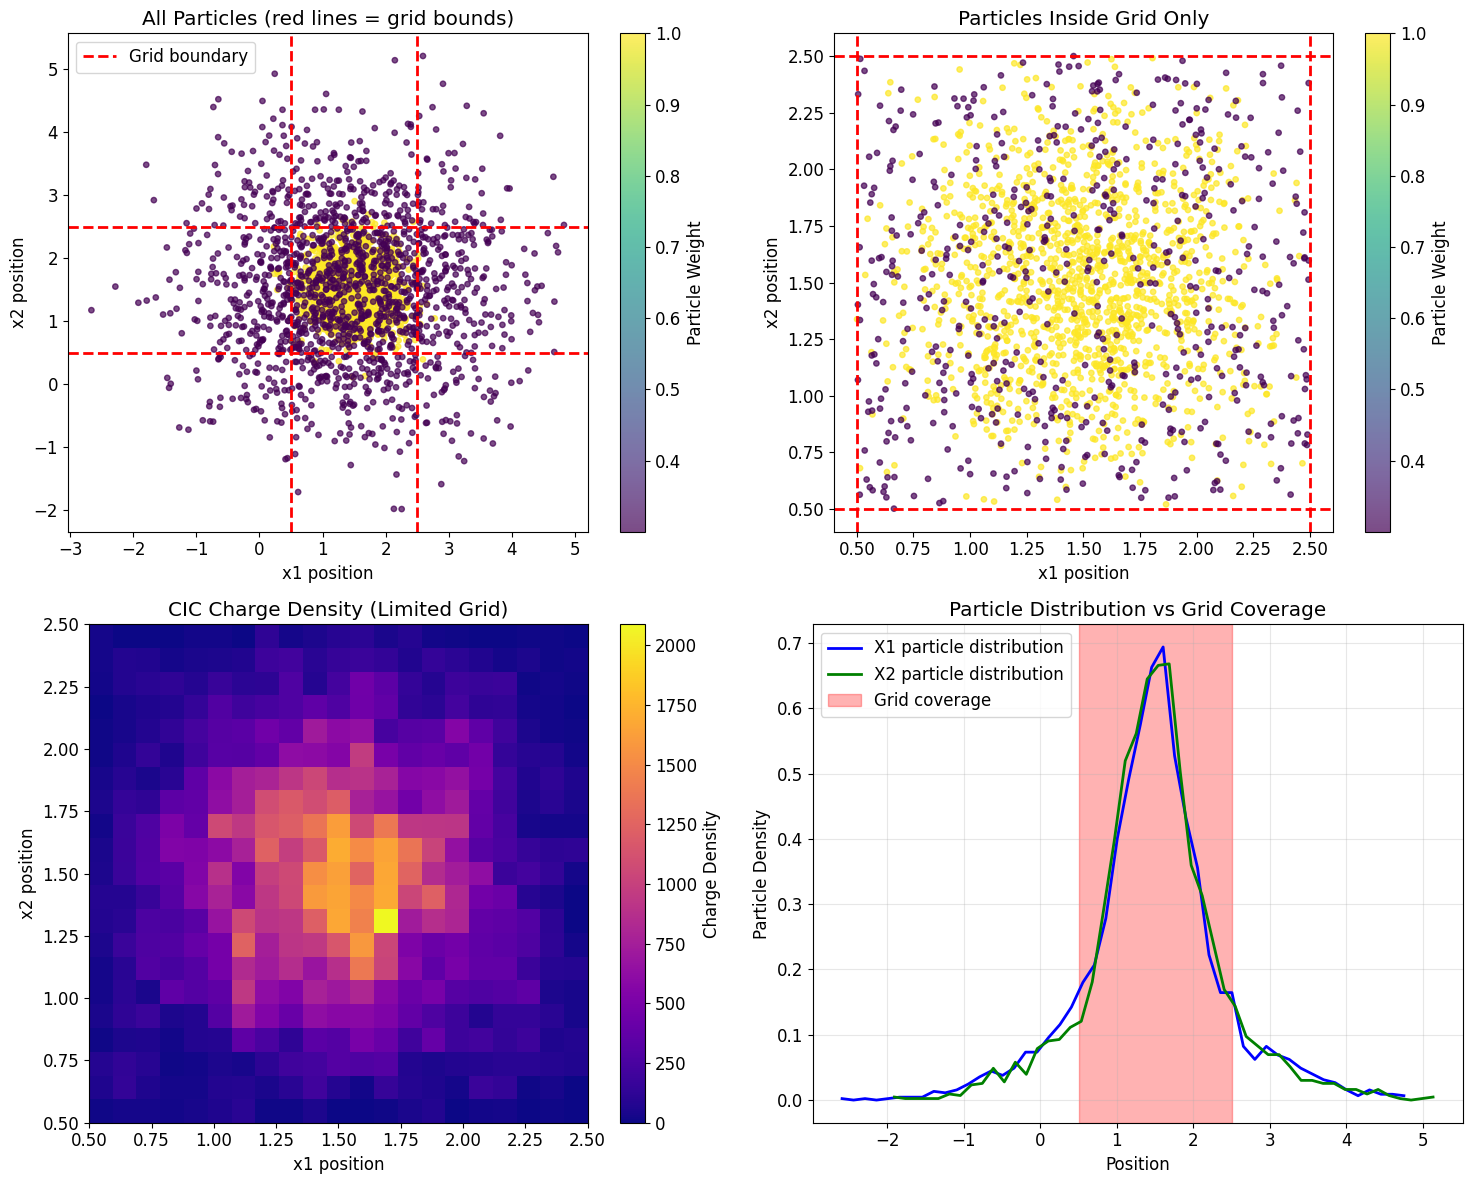


=== Charge Loss Analysis ===
Grid range: [0.5, 2.5]
Particle range X1: [-2.67, 4.83]
Particle range X2: [-1.98, 5.21]
Charge conservation violation: 16.24%


In [ ]:
# Visualize charge loss scenario
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot all particles with grid boundary
scatter_all = axes[0, 0].scatter(
    x1_loss.numpy(),
    x2_loss.numpy(),
    c=weights_loss.numpy(),
    s=15,
    alpha=0.7,
    cmap="viridis",
)
axes[0, 0].axhline(
    y=grid_min, color="red", linestyle="--", linewidth=2, label="Grid boundary"
)
axes[0, 0].axhline(y=grid_max, color="red", linestyle="--", linewidth=2)
axes[0, 0].axvline(x=grid_min, color="red", linestyle="--", linewidth=2)
axes[0, 0].axvline(x=grid_max, color="red", linestyle="--", linewidth=2)
axes[0, 0].set_xlabel("x1 position")
axes[0, 0].set_ylabel("x2 position")
axes[0, 0].set_title("All Particles (red lines = grid bounds)")
axes[0, 0].legend()
axes[0, 0].set_aspect("equal")
plt.colorbar(scatter_all, ax=axes[0, 0], label="Particle Weight")

# Plot only particles inside grid
particles_inside = ~particles_outside
if particles_inside.any():
    scatter_inside = axes[0, 1].scatter(
        x1_loss[particles_inside].numpy(),
        x2_loss[particles_inside].numpy(),
        c=weights_loss[particles_inside].numpy(),
        s=15,
        alpha=0.7,
        cmap="viridis",
    )
    plt.colorbar(scatter_inside, ax=axes[0, 1], label="Particle Weight")

# Add grid boundary
axes[0, 1].axhline(y=grid_min, color="red", linestyle="--", linewidth=2)
axes[0, 1].axhline(y=grid_max, color="red", linestyle="--", linewidth=2)
axes[0, 1].axvline(x=grid_min, color="red", linestyle="--", linewidth=2)
axes[0, 1].axvline(x=grid_max, color="red", linestyle="--", linewidth=2)
axes[0, 1].set_xlabel("x1 position")
axes[0, 1].set_ylabel("x2 position")
axes[0, 1].set_title("Particles Inside Grid Only")
axes[0, 1].set_aspect("equal")
axes[0, 1].set_xlim(grid_min - 0.1, grid_max + 0.1)
axes[0, 1].set_ylim(grid_min - 0.1, grid_max + 0.1)

# Plot charge density with limited grid
im_loss = axes[1, 0].imshow(
    charge_density_loss.T.numpy(),
    origin="lower",
    extent=[grid_min, grid_max, grid_min, grid_max],
    cmap="plasma",
    aspect="equal",
)
axes[1, 0].set_xlabel("x1 position")
axes[1, 0].set_ylabel("x2 position")
axes[1, 0].set_title("CIC Charge Density (Limited Grid)")
plt.colorbar(im_loss, ax=axes[1, 0], label="Charge Density")

# Create histogram showing particle distribution vs grid coverage
x1_hist, x1_edges = torch.histogram(x1_loss, bins=50, density=True)
x2_hist, x2_edges = torch.histogram(x2_loss, bins=50, density=True)

x1_centers = (x1_edges[:-1] + x1_edges[1:]) / 2
x2_centers = (x2_edges[:-1] + x2_edges[1:]) / 2

axes[1, 1].plot(
    x1_centers.numpy(),
    x1_hist.numpy(),
    "b-",
    linewidth=2,
    label="X1 particle distribution",
)
axes[1, 1].plot(
    x2_centers.numpy(),
    x2_hist.numpy(),
    "g-",
    linewidth=2,
    label="X2 particle distribution",
)
axes[1, 1].axvspan(grid_min, grid_max, alpha=0.3, color="red", label="Grid coverage")
axes[1, 1].set_xlabel("Position")
axes[1, 1].set_ylabel("Particle Density")
axes[1, 1].set_title("Particle Distribution vs Grid Coverage")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed analysis
print("\n=== Charge Loss Analysis ===")
print(f"Grid range: [{grid_min:.1f}, {grid_max:.1f}]")
print(f"Particle range X1: [{x1_loss.min():.2f}, {x1_loss.max():.2f}]")
print(f"Particle range X2: [{x2_loss.min():.2f}, {x2_loss.max():.2f}]")
print(
    f"Charge conservation violation: {100 * (1 - total_charge_loss/weights_loss.sum()):.2f}%"
)

## 3D Charge Deposition Example

Finally, let's demonstrate 3D charge deposition with particles distributed in 3D space. We'll create a more complex distribution and visualize cross-sections.


In [8]:
# Create 3D particle distribution
torch.manual_seed(456)
n_particles_3d = 50000

# Distribution 1: 3D Gaussian blob
x1_3d_gauss = torch.randn(n_particles_3d // 3) * 0.2 + 1.0
x2_3d_gauss = torch.randn(n_particles_3d // 3) * 0.2 + 1.0
x3_3d_gauss = torch.randn(n_particles_3d // 3) * 0.2 + 1.0

# Distribution 2: Spiral structure
t = torch.linspace(0, 4 * np.pi, n_particles_3d // 3)
radius = torch.linspace(0.5, 1.0, n_particles_3d // 3)
x1_3d_spiral = 2.0 + radius * torch.cos(t)
x2_3d_spiral = 2.0 + radius * torch.sin(t)
x3_3d_spiral = 1.0 + t / (2 * np.pi)  # Rising spiral

# Add some noise to spiral
x1_3d_spiral += torch.randn(n_particles_3d // 3) * 0.05
x2_3d_spiral += torch.randn(n_particles_3d // 3) * 0.05
x3_3d_spiral += torch.randn(n_particles_3d // 3) * 0.05

# Distribution 3: Linear distribution along a line with nonzero slope
n_line = n_particles_3d - 2 * (n_particles_3d // 3)  # Handle remainder
t_line = torch.linspace(0, 1, n_line)
# Line from (0.5, 0.5, 0.5) to (2.5, 1.5, 2.5) with slopes in all directions
x1_3d_line = 0.5 + t_line * 2.0  # slope = 2.0 in x1
x2_3d_line = 0.5 + t_line * 1.0  # slope = 1.0 in x2
x3_3d_line = 0.5 + t_line * 2.0  # slope = 2.0 in x3

# Add some noise to make the line more realistic (small scatter around the line)
x1_3d_line += torch.randn(n_line) * 0.03
x2_3d_line += torch.randn(n_line) * 0.03
x3_3d_line += torch.randn(n_line) * 0.03

# Combine distributions
x1_3d = torch.cat([x1_3d_gauss, x1_3d_spiral, x1_3d_line])
x2_3d = torch.cat([x2_3d_gauss, x2_3d_spiral, x2_3d_line])
x3_3d = torch.cat([x3_3d_gauss, x3_3d_spiral, x3_3d_line])

# Different weights for each distribution
weights_3d = torch.cat(
    [
        torch.ones(n_particles_3d // 3) * 2.0,  # Gaussian particles
        torch.ones(n_particles_3d // 3) * 0.5,  # Spiral particles
        torch.ones(n_line) * 1.0,  # Line particles
    ]
)

# Define 3D grid (smaller for computational efficiency)
x1_bins_3d = torch.linspace(0, 3, 100)  # 24x24x24 grid
x2_bins_3d = torch.linspace(0, 3, 150)
x3_bins_3d = torch.linspace(0, 3, 125)

# Perform 3D CIC charge deposition
charge_density_3d = cloud_in_cell_charge_deposition_3d(
    x1_3d, x2_3d, x3_3d, x1_bins_3d, x2_bins_3d, x3_bins_3d, weights_3d
)

total_charge_3d = charge_density_3d.sum().item() * (
    (x1_bins_3d[1] - x1_bins_3d[0])
    * (x2_bins_3d[1] - x2_bins_3d[0])
    * (x3_bins_3d[1] - x3_bins_3d[0])
)

print(f"3D Grid shape: {charge_density_3d.shape}")
print(f"Total charge deposited: {total_charge_3d:.2f}")
print(f"Expected total charge: {weights_3d.sum():.2f}")
print(
    f"Charge conservation error: {abs(total_charge_3d - weights_3d.sum()) / weights_3d.sum():.2e}"
)
print(f"Maximum charge density: {charge_density_3d.max():.4f}")

3D Grid shape: torch.Size([100, 150, 125])
Total charge deposited: 58196.50
Expected total charge: 58333.00
Charge conservation error: 2.34e-03
Maximum charge density: 1222522.3750


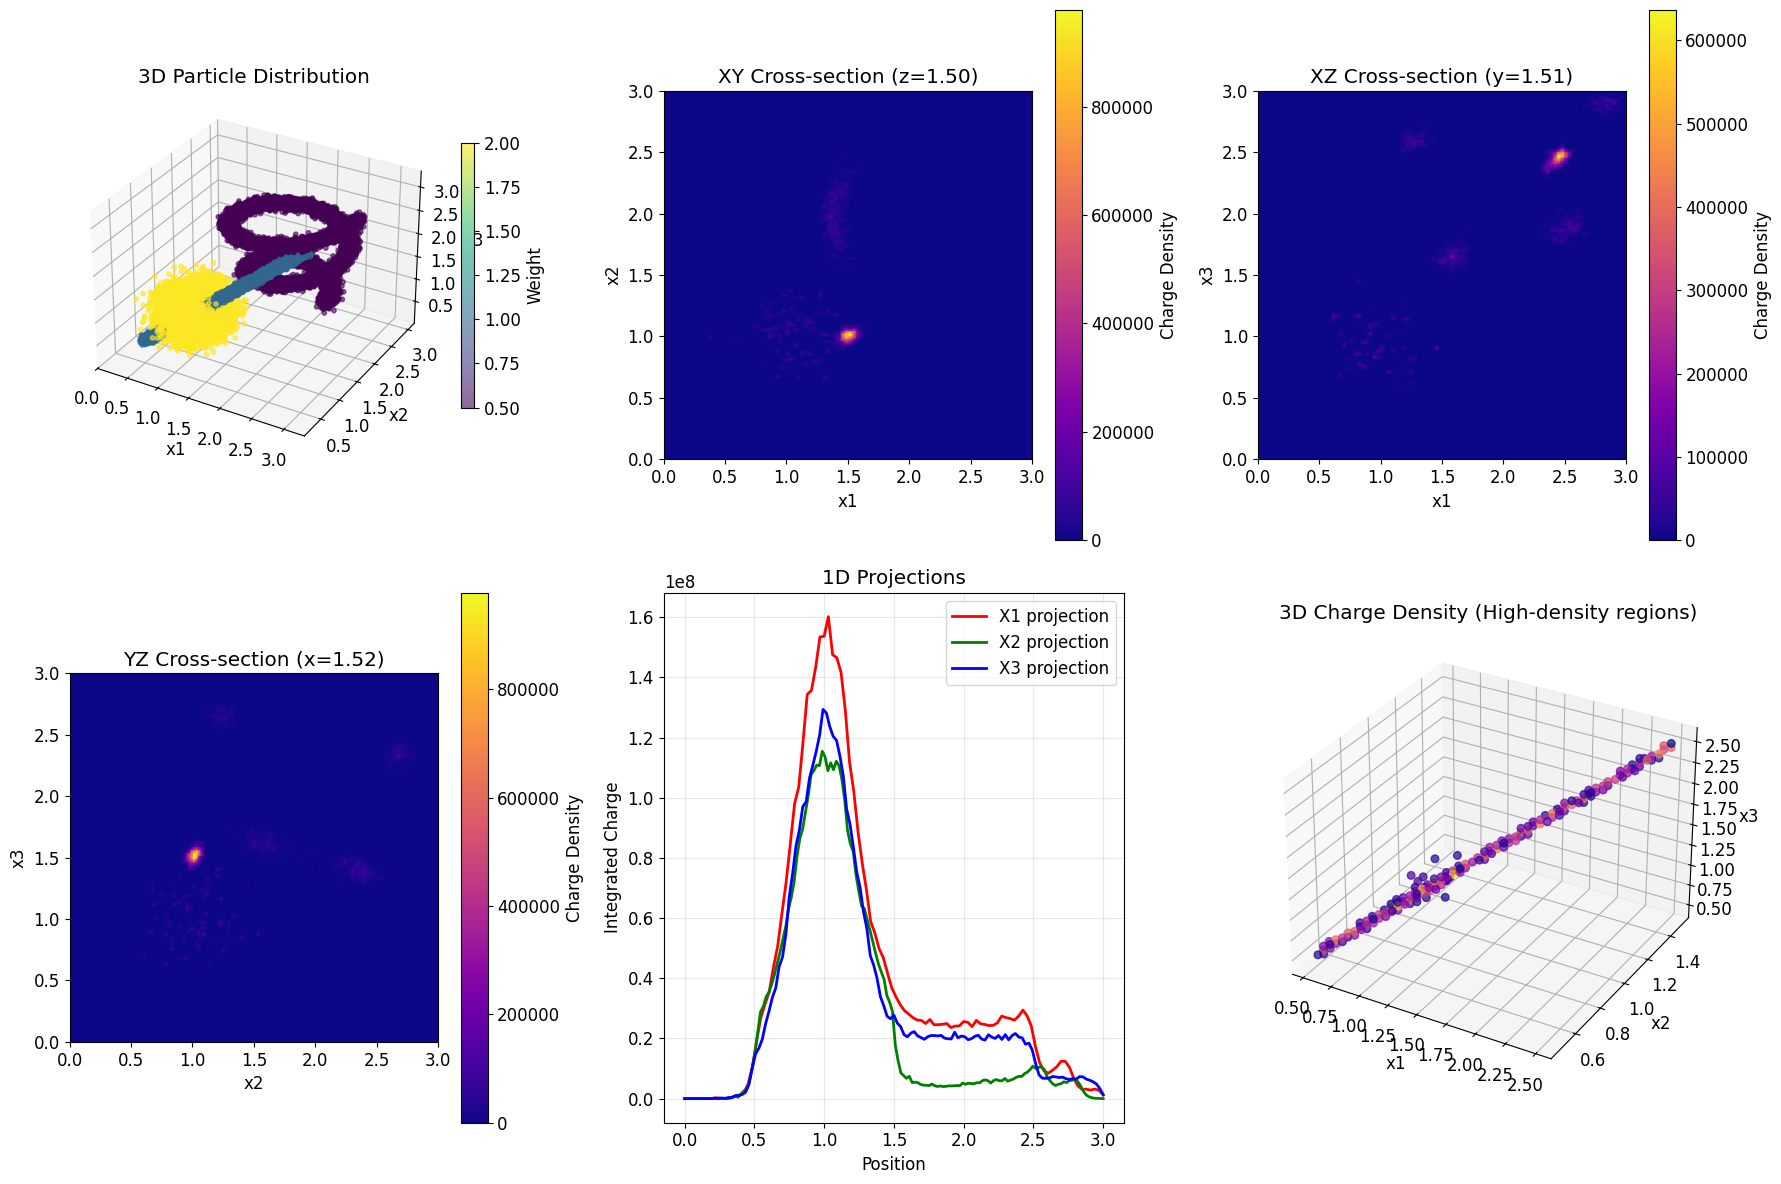

In [9]:
# Plot 3D results - particle distribution and cross-sections
fig = plt.figure(figsize=(18, 12))

# 3D scatter plot of particles
ax1 = fig.add_subplot(231, projection="3d")
scatter = ax1.scatter(
    x1_3d.numpy(),
    x2_3d.numpy(),
    x3_3d.numpy(),
    c=weights_3d.numpy(),
    s=10,
    alpha=0.6,
    cmap="viridis",
)
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")
ax1.set_zlabel("x3")
ax1.set_title("3D Particle Distribution")
plt.colorbar(scatter, ax=ax1, shrink=0.5, label="Weight")

# Cross-section at z = middle
z_mid_idx = charge_density_3d.shape[2] // 2
ax2 = fig.add_subplot(232)
im2 = ax2.imshow(
    charge_density_3d[:, :, z_mid_idx].T.numpy(),
    origin="lower",
    cmap="plasma",
    extent=[x1_bins_3d[0], x1_bins_3d[-1], x2_bins_3d[0], x2_bins_3d[-1]],
)
ax2.set_xlabel("x1")
ax2.set_ylabel("x2")
ax2.set_title(f"XY Cross-section (z={x3_bins_3d[z_mid_idx]:.2f})")
plt.colorbar(im2, ax=ax2, label="Charge Density")

# Cross-section at y = middle
y_mid_idx = charge_density_3d.shape[1] // 2
ax3 = fig.add_subplot(233)
im3 = ax3.imshow(
    charge_density_3d[:, y_mid_idx, :].T.numpy(),
    origin="lower",
    cmap="plasma",
    extent=[x1_bins_3d[0], x1_bins_3d[-1], x3_bins_3d[0], x3_bins_3d[-1]],
)
ax3.set_xlabel("x1")
ax3.set_ylabel("x3")
ax3.set_title(f"XZ Cross-section (y={x2_bins_3d[y_mid_idx]:.2f})")
plt.colorbar(im3, ax=ax3, label="Charge Density")

# Cross-section at x = middle
x_mid_idx = charge_density_3d.shape[0] // 2
ax4 = fig.add_subplot(234)
im4 = ax4.imshow(
    charge_density_3d[x_mid_idx, :, :].T.numpy(),
    origin="lower",
    cmap="plasma",
    extent=[x2_bins_3d[0], x2_bins_3d[-1], x3_bins_3d[0], x3_bins_3d[-1]],
)
ax4.set_xlabel("x2")
ax4.set_ylabel("x3")
ax4.set_title(f"YZ Cross-section (x={x1_bins_3d[x_mid_idx]:.2f})")
plt.colorbar(im4, ax=ax4, label="Charge Density")

# 1D projections
ax5 = fig.add_subplot(235)
proj_x1 = charge_density_3d.sum(dim=(1, 2))
proj_x2 = charge_density_3d.sum(dim=(0, 2))
proj_x3 = charge_density_3d.sum(dim=(0, 1))

ax5.plot(x1_bins_3d.numpy(), proj_x1.numpy(), "r-", label="X1 projection", linewidth=2)
ax5.plot(x2_bins_3d.numpy(), proj_x2.numpy(), "g-", label="X2 projection", linewidth=2)
ax5.plot(x3_bins_3d.numpy(), proj_x3.numpy(), "b-", label="X3 projection", linewidth=2)
ax5.set_xlabel("Position")
ax5.set_ylabel("Integrated Charge")
ax5.set_title("1D Projections")
ax5.legend()
ax5.grid(True, alpha=0.3)

# Volume rendering (isosurface)
ax6 = fig.add_subplot(236, projection="3d")
# Create a coarser grid for visualization
step = 2
X1_3d, X2_3d, X3_3d = torch.meshgrid(
    x1_bins_3d[::step], x2_bins_3d[::step], x3_bins_3d[::step], indexing="ij"
)
charge_coarse = charge_density_3d[::step, ::step, ::step]

# Plot only high-density regions
threshold = charge_coarse.max() * 0.3
mask = charge_coarse > threshold
if mask.any():
    ax6.scatter(
        X1_3d[mask].numpy(),
        X2_3d[mask].numpy(),
        X3_3d[mask].numpy(),
        c=charge_coarse[mask].numpy(),
        s=30,
        alpha=0.7,
        cmap="plasma",
    )
ax6.set_xlabel("x1")
ax6.set_ylabel("x2")
ax6.set_zlabel("x3")
ax6.set_title("3D Charge Density (High-density regions)")

plt.tight_layout()
plt.show()

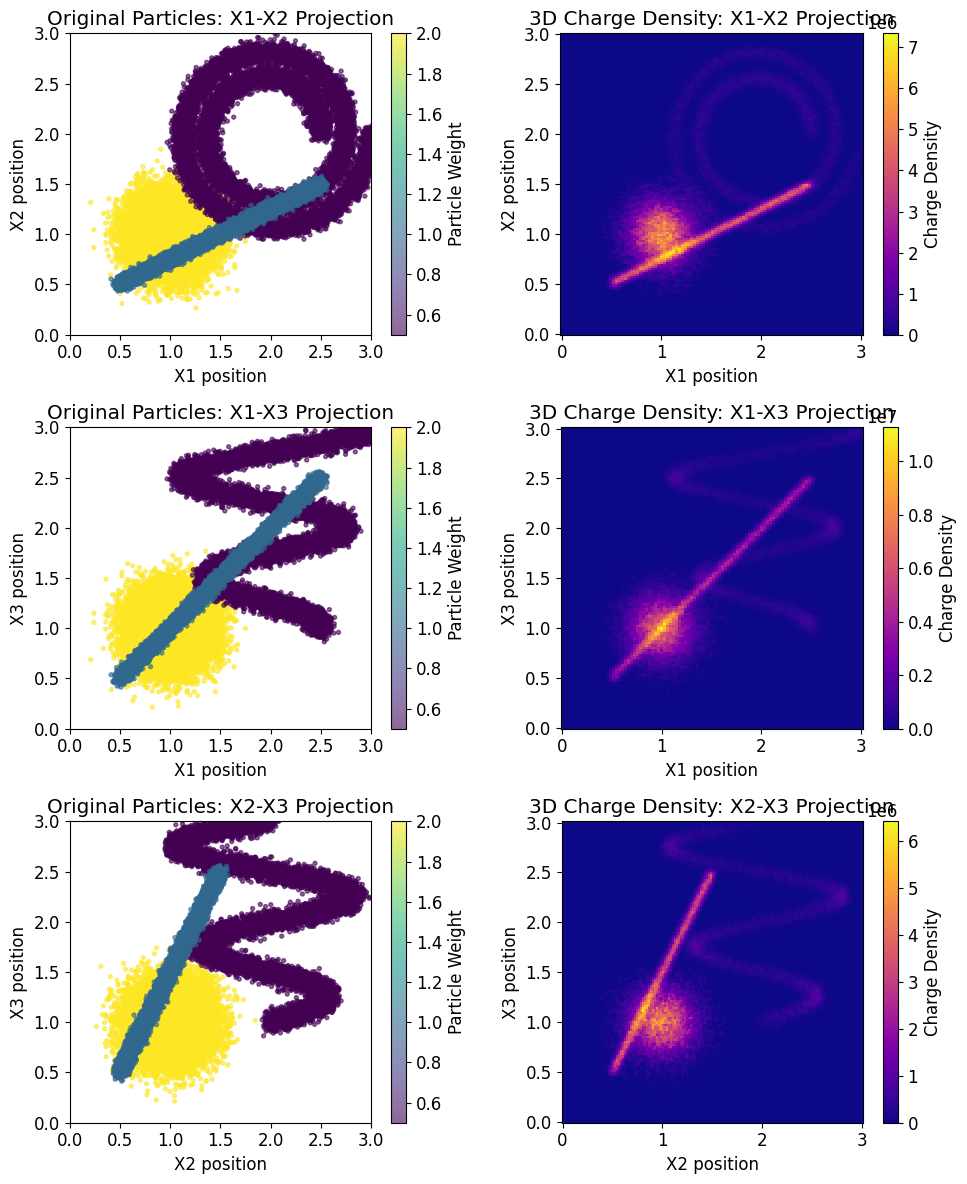

In [10]:
# Project 3D charge distribution and compare with original particle distributions
fig, axes = plt.subplots(3, 2, figsize=(10, 12))

# Calculate projections by summing along each axis

projection_x1x2 = charge_density_3d.sum(
    dim=2
)  # Sum along x3 -> project onto x1-x2 plane
projection_x1x3 = charge_density_3d.sum(
    dim=1
)  # Sum along x2 -> project onto x1-x3 plane
projection_x2x3 = charge_density_3d.sum(
    dim=0
)  # Sum along x1 -> project onto x2-x3 plane

# Plot 1: X1-X2 plane projection
# Original particles as scatter plot
scatter1 = axes[0, 0].scatter(
    x1_3d.numpy(), x2_3d.numpy(), c=weights_3d.numpy(), s=8, alpha=0.6, cmap="viridis"
)
axes[0, 0].set_xlabel("X1 position")
axes[0, 0].set_ylabel("X2 position")
axes[0, 0].set_title("Original Particles: X1-X2 Projection")
axes[0, 0].set_aspect("equal")
axes[0, 0].set_xlim(x1_bins_3d[0], x1_bins_3d[-1])
axes[0, 0].set_ylim(x2_bins_3d[0], x2_bins_3d[-1])
plt.colorbar(scatter1, ax=axes[0, 0], label="Particle Weight")

# 3D charge density projected
X1_mesh, X2_mesh = torch.meshgrid(x1_bins_3d, x2_bins_3d, indexing="ij")
im2 = axes[0, 1].pcolormesh(
    X1_mesh.numpy(), X2_mesh.numpy(), projection_x1x2.numpy(), cmap="plasma"
)
axes[0, 1].set_xlabel("X1 position")
axes[0, 1].set_ylabel("X2 position")
axes[0, 1].set_title("3D Charge Density: X1-X2 Projection")
axes[0, 1].set_aspect("equal")
plt.colorbar(im2, ax=axes[0, 1], label="Charge Density")

# Plot 2: X1-X3 plane projection
# Original particles as scatter plot
scatter3 = axes[1, 0].scatter(
    x1_3d.numpy(), x3_3d.numpy(), c=weights_3d.numpy(), s=8, alpha=0.6, cmap="viridis"
)
axes[1, 0].set_xlabel("X1 position")
axes[1, 0].set_ylabel("X3 position")
axes[1, 0].set_title("Original Particles: X1-X3 Projection")
axes[1, 0].set_aspect("equal")
axes[1, 0].set_xlim(x1_bins_3d[0], x1_bins_3d[-1])
axes[1, 0].set_ylim(x3_bins_3d[0], x3_bins_3d[-1])
plt.colorbar(scatter3, ax=axes[1, 0], label="Particle Weight")

# 3D charge density projected
X1_mesh, X3_mesh = torch.meshgrid(x1_bins_3d, x3_bins_3d, indexing="ij")
im4 = axes[1, 1].pcolormesh(
    X1_mesh.numpy(), X3_mesh.numpy(), projection_x1x3.numpy(), cmap="plasma"
)
axes[1, 1].set_xlabel("X1 position")
axes[1, 1].set_ylabel("X3 position")
axes[1, 1].set_title("3D Charge Density: X1-X3 Projection")
axes[1, 1].set_aspect("equal")
plt.colorbar(im4, ax=axes[1, 1], label="Charge Density")

# Plot 3: X2-X3 plane projection
# Original particles as scatter plot
scatter5 = axes[2, 0].scatter(
    x2_3d.numpy(), x3_3d.numpy(), c=weights_3d.numpy(), s=8, alpha=0.6, cmap="viridis"
)
axes[2, 0].set_xlabel("X2 position")
axes[2, 0].set_ylabel("X3 position")
axes[2, 0].set_title("Original Particles: X2-X3 Projection")
axes[2, 0].set_aspect("equal")
axes[2, 0].set_xlim(x2_bins_3d[0], x2_bins_3d[-1])
axes[2, 0].set_ylim(x3_bins_3d[0], x3_bins_3d[-1])
plt.colorbar(scatter5, ax=axes[2, 0], label="Particle Weight")

# 3D charge density projected
X2_mesh, X3_mesh = torch.meshgrid(x2_bins_3d, x3_bins_3d, indexing="ij")
im6 = axes[2, 1].pcolormesh(
    X2_mesh.numpy(), X3_mesh.numpy(), projection_x2x3.numpy(), cmap="plasma"
)
axes[2, 1].set_xlabel("X2 position")
axes[2, 1].set_ylabel("X3 position")
axes[2, 1].set_title("3D Charge Density: X2-X3 Projection")
axes[2, 1].set_aspect("equal")
plt.colorbar(im6, ax=axes[2, 1], label="Charge Density")

plt.tight_layout()
plt.show()

## Batched Processing Example

The CIC functions support batched processing, which is useful when you have multiple time steps or different beam configurations to process simultaneously.


In [11]:
# Demonstrate batched processing
torch.manual_seed(789)
n_batches = 3
n_particles_batch = 1000

# Create batched 2D particle data
# Each batch represents a different time step with evolving distribution
x1_batch = torch.zeros(n_batches, n_particles_batch)
x2_batch = torch.zeros(n_batches, n_particles_batch)
weights_batch = torch.ones(n_batches, n_particles_batch)

for i in range(n_batches):
    # Evolving Gaussian distribution
    center = 1.5 + i * 0.5  # Moving center
    width = 0.3 + i * 0.1  # Expanding width

    x1_batch[i] = torch.randn(n_particles_batch) * width + center
    x2_batch[i] = (
        torch.randn(n_particles_batch) * width + 1.5 * center
    )  # make assymetric across x1=x2 line

    # Different total charge for each batch
    weights_batch[i] *= 1.0 + i * 0.5

# Define grid for batched processing
bins_batch = torch.linspace(0, 4, 31)

# Process all batches at once
charge_density_batch = cloud_in_cell_charge_deposition_2d(
    x1_batch, x2_batch, bins_batch, bins_batch, weights_batch
)

print(f"Batched result shape: {charge_density_batch.shape}")
print(f"Total charges per batch: {charge_density_batch.sum(dim=(1,2))}")
print(f"Expected charges per batch: {weights_batch.sum(dim=1)}")

Batched result shape: torch.Size([3, 31, 31])
Total charges per batch: tensor([56249.9922, 83699.9922, 78299.9844])
Expected charges per batch: tensor([1000., 1500., 2000.])


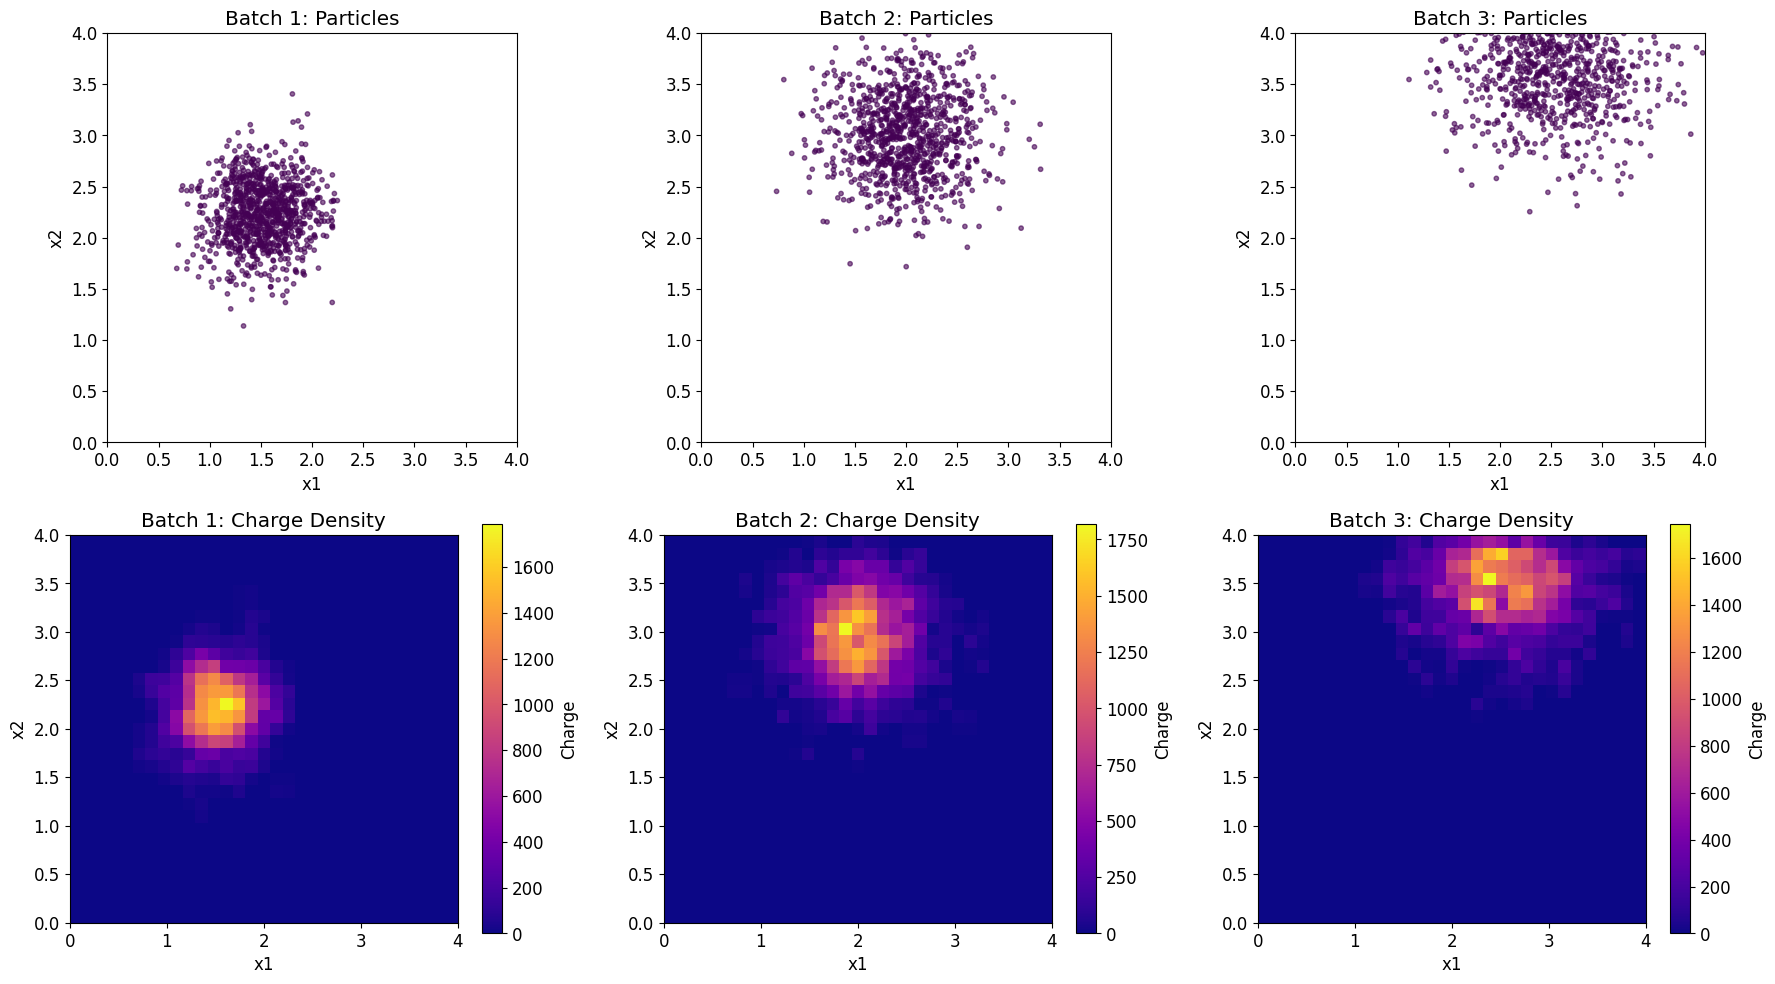

In [12]:
# Plot batched results
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i in range(n_batches):
    # Plot particle positions
    axes[0, i].scatter(
        x1_batch[i].numpy(),
        x2_batch[i].numpy(),
        s=10,
        alpha=0.6,
        c=weights_batch[i].numpy(),
        cmap="viridis",
    )
    axes[0, i].set_xlabel("x1")
    axes[0, i].set_ylabel("x2")
    axes[0, i].set_title(f"Batch {i+1}: Particles")
    axes[0, i].set_aspect("equal")
    axes[0, i].set_xlim(0, 4)
    axes[0, i].set_ylim(0, 4)

    # Plot charge density
    im = axes[1, i].imshow(
        charge_density_batch[i].T.numpy(),
        origin="lower",
        cmap="plasma",
        extent=[bins_batch[0], bins_batch[-1], bins_batch[0], bins_batch[-1]],
    )
    axes[1, i].set_xlabel("x1")
    axes[1, i].set_ylabel("x2")
    axes[1, i].set_title(f"Batch {i+1}: Charge Density")
    axes[1, i].set_aspect("equal")
    plt.colorbar(im, ax=axes[1, i], label="Charge")

plt.tight_layout()
plt.show()

## Performance Comparison and Analysis

Let's compare the performance of different grid resolutions and analyze the accuracy of the CIC method.


Grid 20x20: 0.0013 s, Memory: 0.00 MB
Grid 40x40: 0.0010 s, Memory: 0.01 MB
Grid 80x80: 0.0007 s, Memory: 0.03 MB
Grid 160x160: 0.0010 s, Memory: 0.10 MB


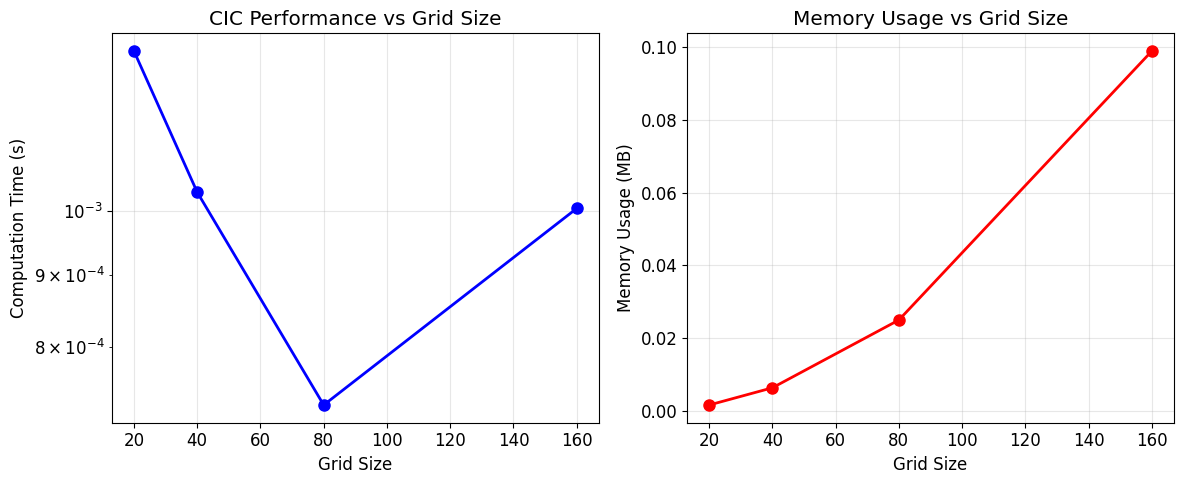

In [13]:
import time

# Performance test with different grid sizes
torch.manual_seed(999)
n_particles_perf = 10000

# Generate test particles
x1_perf = torch.randn(n_particles_perf) * 0.5 + 2.0
x2_perf = torch.randn(n_particles_perf) * 0.5 + 2.0
weights_perf = torch.ones(n_particles_perf)

# Test different grid resolutions
grid_sizes = [20, 40, 80, 160]
times = []
memory_usage = []

for grid_size in grid_sizes:
    bins_perf = torch.linspace(0, 4, grid_size + 1)

    # Measure time
    start_time = time.time()
    result = cloud_in_cell_charge_deposition_2d(
        x1_perf, x2_perf, bins_perf, bins_perf, weights_perf
    )
    end_time = time.time()

    times.append(end_time - start_time)
    memory_usage.append(result.numel() * result.element_size() / 1024 / 1024)  # MB

    print(
        f"Grid {grid_size}x{grid_size}: {end_time - start_time:.4f} s, "
        f"Memory: {memory_usage[-1]:.2f} MB"
    )

# Plot performance results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(grid_sizes, times, "bo-", linewidth=2, markersize=8)
ax1.set_xlabel("Grid Size")
ax1.set_ylabel("Computation Time (s)")
ax1.set_title("CIC Performance vs Grid Size")
ax1.grid(True, alpha=0.3)
ax1.set_yscale("log")

ax2.plot(grid_sizes, memory_usage, "ro-", linewidth=2, markersize=8)
ax2.set_xlabel("Grid Size")
ax2.set_ylabel("Memory Usage (MB)")
ax2.set_title("Memory Usage vs Grid Size")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Error Analysis and Convergence

Finally, let's analyze how the CIC method converges as we increase the grid resolution and examine the interpolation accuracy.


Grid 20x20: Relative error = 0.007556
Grid 40x40: Relative error = 0.004958
Grid 60x60: Relative error = 0.006532
Grid 80x80: Relative error = 0.008297
Grid 100x100: Relative error = 0.010250


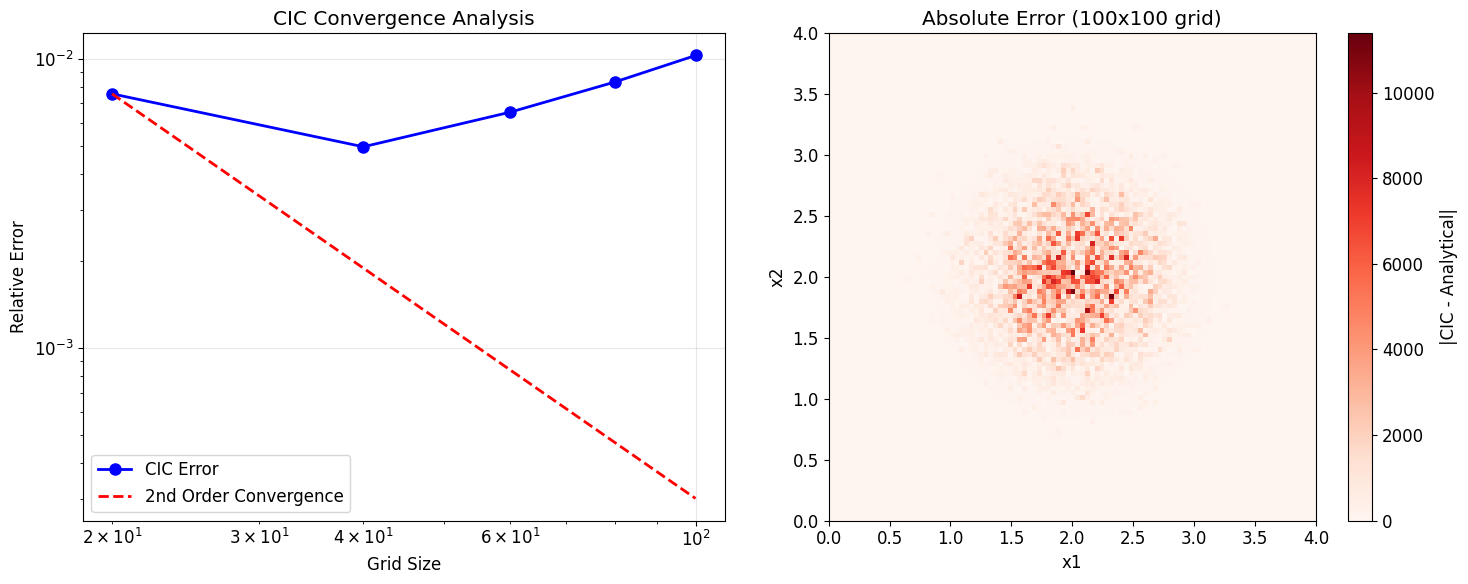


Final relative error (100x100 grid): 0.010250
Maximum absolute error: 11388.398438


In [14]:
# Convergence analysis with analytical test case
def analytical_gaussian_2d(
    X, Y, x0=2.0, y0=2.0, sigma_x=0.5, sigma_y=0.5, amplitude=1.0
):
    """Analytical 2D Gaussian for comparison."""
    return amplitude * torch.exp(
        -0.5 * ((X - x0) ** 2 / sigma_x**2 + (Y - y0) ** 2 / sigma_y**2)
    )


# Parameters for analytical case
x0, y0 = 2.0, 2.0
sigma_x, sigma_y = 0.3, 0.3

# Generate particles from the analytical distribution
torch.manual_seed(42)
n_particles_conv = 50000

x1_conv = torch.randn(n_particles_conv) * sigma_x + x0
x2_conv = torch.randn(n_particles_conv) * sigma_y + y0
weights_conv = torch.ones(n_particles_conv)

# Test convergence with different grid resolutions
grid_sizes_conv = [20, 40, 60, 80, 100]
errors = []

for grid_size in grid_sizes_conv:
    bins_conv = torch.linspace(0, 4, grid_size + 1)

    # CIC result
    cic_result = cloud_in_cell_charge_deposition_2d(
        x1_conv, x2_conv, bins_conv, bins_conv, weights_conv
    )

    # Analytical result
    X_anal, Y_anal = torch.meshgrid(bins_conv, bins_conv, indexing="ij")
    analytical_result = analytical_gaussian_2d(X_anal, Y_anal, x0, y0, sigma_x, sigma_y)

    # Normalize analytical result to match total charge
    analytical_result = analytical_result * cic_result.sum() / analytical_result.sum()

    # Calculate relative error
    error = (
        torch.sqrt(((cic_result - analytical_result) ** 2).mean())
        / analytical_result.max()
    )
    errors.append(error.item())

    print(f"Grid {grid_size}x{grid_size}: Relative error = {error:.6f}")

# Plot convergence
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.loglog(grid_sizes_conv, errors, "bo-", linewidth=2, markersize=8, label="CIC Error")
# Add theoretical convergence line (2nd order for CIC)
theoretical = [errors[0] * (grid_sizes_conv[0] / g) ** 2 for g in grid_sizes_conv]
ax1.loglog(
    grid_sizes_conv, theoretical, "r--", linewidth=2, label="2nd Order Convergence"
)
ax1.set_xlabel("Grid Size")
ax1.set_ylabel("Relative Error")
ax1.set_title("CIC Convergence Analysis")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Show comparison for highest resolution
bins_final = torch.linspace(0, 4, 101)
cic_final = cloud_in_cell_charge_deposition_2d(
    x1_conv, x2_conv, bins_final, bins_final, weights_conv
)
X_final, Y_final = torch.meshgrid(bins_final, bins_final, indexing="ij")
anal_final = analytical_gaussian_2d(X_final, Y_final, x0, y0, sigma_x, sigma_y)
anal_final = anal_final * cic_final.sum() / anal_final.sum()

diff = torch.abs(cic_final - anal_final)
im = ax2.imshow(
    diff.T.numpy(),
    origin="lower",
    cmap="Reds",
    extent=[bins_final[0], bins_final[-1], bins_final[0], bins_final[-1]],
)
ax2.set_xlabel("x1")
ax2.set_ylabel("x2")
ax2.set_title("Absolute Error (100x100 grid)")
ax2.set_aspect("equal")
plt.colorbar(im, ax=ax2, label="|CIC - Analytical|")

plt.tight_layout()
plt.show()

print(f"\nFinal relative error (100x100 grid): {errors[-1]:.6f}")
print(f"Maximum absolute error: {diff.max():.6f}")